In [1]:
import csv
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np


In [ ]:

# Function to plot the box chart with correct x-axis distribution
def plot_box_chart(data):
    # Group data by x and model
    grouped_data = defaultdict(lambda: defaultdict(list))
    for entry in data:
        grouped_data[entry['x']][entry['model']].append(entry['y'])

    # Prepare data for plotting
    x_values = sorted(grouped_data.keys())  # Unique x values


    print(x_values)

    
    models = [file.split('/')[-1].split('_')[0].upper() for file in file_list]  # Use file_list order
    box_data = {model: [] for model in models}
    mean_data = {model: [] for model in models}
    
    for x in x_values:
        for model in models:
            model_data = grouped_data[x].get(model, [])
            box_data[model].append(model_data)
            mean_data[model].append(np.mean(model_data) if model_data else None)

    # Plot
    plt.figure(figsize=(10, 5))
    colors = plt.cm.tab10(np.arange(len(models)))  # Use tab10 colors

    for i, model in enumerate(models):
        # Adjust x positions based on actual x_values
        positions = [x for x in x_values]
        bp = plt.boxplot(
            box_data[model],
            positions=positions,
            widths=0.15 * (x_values[-1] - x_values[0]) / len(x_values),  # Scale width dynamically
            patch_artist=True,
            boxprops=dict(facecolor=colors[i], color=colors[i]),
            whiskerprops=dict(color=colors[i], linewidth=1),
            medianprops=dict(color="black"),
            flierprops=dict(markerfacecolor=colors[i], markeredgecolor=colors[i], marker='o', markersize=3),
        )
        
    # Customize the plot
    plt.yscale('log')
    # plt.title('Box Chart for Different Models with Correct X-Axis Distribution', fontsize=16)
    plt.xlabel('Number of parameters', fontsize=12)
    plt.ylabel('Loss (Log scale)', fontsize=12)
    plt.xticks(ticks=x_values, labels=[str(int(x)) for x in x_values], rotation=60)
    
    # Create a custom legend
    handles = [plt.Line2D([0], [0], color=colors[i], lw=4, label=models[i]) for i in range(len(models))]
    plt.legend(handles=handles, title="Model", loc="upper right", fontsize=10)
    
    plt.tight_layout()

    # Save and display the plot
    plt.savefig("log_box_chart_correct_x.png")
    plt.show()
    print("Chart saved as log_box_chart_correct_x.png")


In [ ]:
# List the uploaded files (adjust paths if necessary)
file_list = [
    './qgru_test.csv',
    './gru_test.csv',
    './lstm_test.csv',
    # './rnn_train.csv'
]

# Load data and generate the plot
data = load_data(file_list)
plot_box_chart(data)


In [ ]:
# List the uploaded files (adjust paths if necessary)
file_list = [
    './qgru_train.csv',
    './gru_train.csv',
    './lstm_train.csv',
    # './rnn_train.csv'
]

# Load data and generate the plot
data = load_data(file_list)
plot_box_chart(data)


In [4]:
# Function to load data from uploaded files
def load_data(file_list):
    data = []
    for file in file_list:
        # Extract model name from file name (e.g., "qgru_train.csv" -> "QGRU")
        model_name = file.split('/')[-1].split('_')[0].upper()
        # Read the file
        with open(file, 'r') as f:
            reader = csv.reader(f)
            header = next(reader)  # Skip the header
            x_axis_label = header[0]  # First column is # of parameters
            
            for row in reader:
                x_value = float(row[0])  # First column as x-axis
                for i, y_value in enumerate(row[1:]):  # Iterate over the remaining columns
                    if y_value:  # Skip empty values
                        data.append({"x": x_value, "y": float(y_value), "model": model_name})
    return data


def adjust_x_positions_for_labels(x_values, min_distance=5):
    """
    Adjust x positions for labels to avoid overlap.
    
    Parameters:
        x_values (list of float): Original x positions.
        min_distance (float): Minimum distance between adjusted positions.
        
    Returns:
        list of float: Adjusted x positions for labels.
    """
    adjusted = x_values.copy()
    for i in range(1, len(adjusted)):
        if adjusted[i] - adjusted[i - 1] < min_distance:
            # Calculate offset to distribute the positions
            offset = (min_distance - (adjusted[i] - adjusted[i - 1])) / 2
            adjusted[i - 1] -= offset
            adjusted[i] += offset
    return adjusted

In [28]:
def plot_box_chart_with_dual_xticks(data, title='Box Chart with Dual X-Axis Ticks',
                                    xlabel='# of Parameters', ylabel='Values (Log Scale)',
                                    png_file='log_box_chart_dual_xticks_fixed'):
    # Group data by x and model
    grouped_data = defaultdict(lambda: defaultdict(list))
    for entry in data:
        grouped_data[entry['x']][entry['model']].append(entry['y'])

    # Prepare data for plotting
    x_values = sorted(grouped_data.keys())  # Unique x values
    models = [file.split('/')[-1].split('_')[0].upper() for file in file_list]  # Use file_list order
    box_data = {model: [] for model in models}
    mean_data = {model: [] for model in models}
    
    for x in x_values:
        for model in models:
            model_data = grouped_data[x].get(model, [])
            box_data[model].append(model_data)
            mean_data[model].append(np.mean(model_data) if model_data else None)

    # Adjust x positions for labels (only for display)
    adjusted_x_values = adjust_x_positions_for_labels(x_values, min_distance=17)

    # Plot
    plt.figure(figsize=(10, 5))
    colors = plt.cm.tab10(np.arange(len(models)))  # Use tab10 colors

    for i, model in enumerate(models):
        # Use original x_values for data positions
        positions = x_values
        bp = plt.boxplot(
            box_data[model],
            positions=positions,
            widths=0.2 * (x_values[-1] - x_values[0]) / len(x_values),  # Scale width dynamically
            patch_artist=True,
            boxprops=dict(facecolor=colors[i], color=colors[i]),
            whiskerprops=dict(color=colors[i], linewidth=2),
            medianprops=dict(color="black"),
            flierprops=dict(markerfacecolor=colors[i], markeredgecolor=colors[i], marker='o', markersize=3),
        )
        
    # Customize the plot
    plt.yscale('log')
    # plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12, labelpad=14)
    plt.ylabel(ylabel, fontsize=12)
    
    # Add dual xticks
    # plt.xticks(ticks=x_values, labels=[str(int(x)) for x in x_values], rotation=0)  # Fixed main ticks
    plt.xticks(ticks=x_values, labels=['   ' for x in x_values], rotation=0)  # Fixed main ticks
    for i, (adj_x, orig_x) in enumerate(zip(adjusted_x_values, x_values)):
        plt.text(adj_x, plt.gca().get_ylim()[0] * 0.8,  # 垂直位置稍微調整，避免過低
                 str(int(orig_x)), 
                 ha='center', 
                 va='top', 
                 rotation=60, 
                 fontsize=10, 
                 transform=plt.gca().transData)

    # Create a custom legend
    handles = [plt.Line2D([0], [0], color=colors[i], lw=4, label=models[i]) for i in range(len(models))]
    plt.legend(handles=handles, title="Model", loc="best", fontsize=10)
    
    plt.tight_layout()

    # Save and display the plot
    plt.savefig(png_file + '.png')
    plt.show()
    print('Chart saved as ' + png_file + '.png')


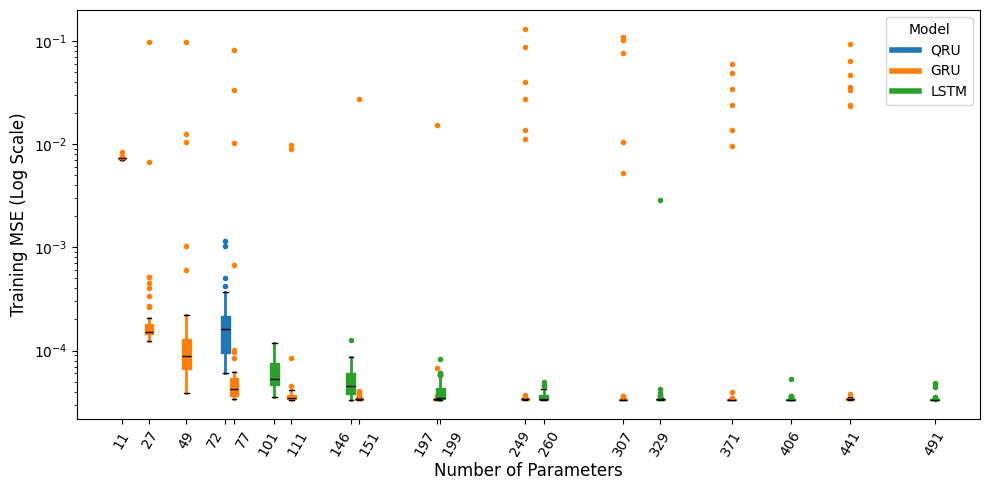

Chart saved as Training MSE.png


In [29]:
# List the uploaded files (adjust paths if necessary)
file_list = [
    './qru_train.csv',
    './gru_train.csv',
    './lstm_train - 2.csv',
    # './rnn_train.csv'
]

# Load data and generate the plot
data = load_data(file_list)
plot_box_chart_with_dual_xticks(data, 'Training MSE Distribution Across Parameter Counts',
                                'Number of Parameters', 'Training MSE (Log Scale)', 'Training MSE')


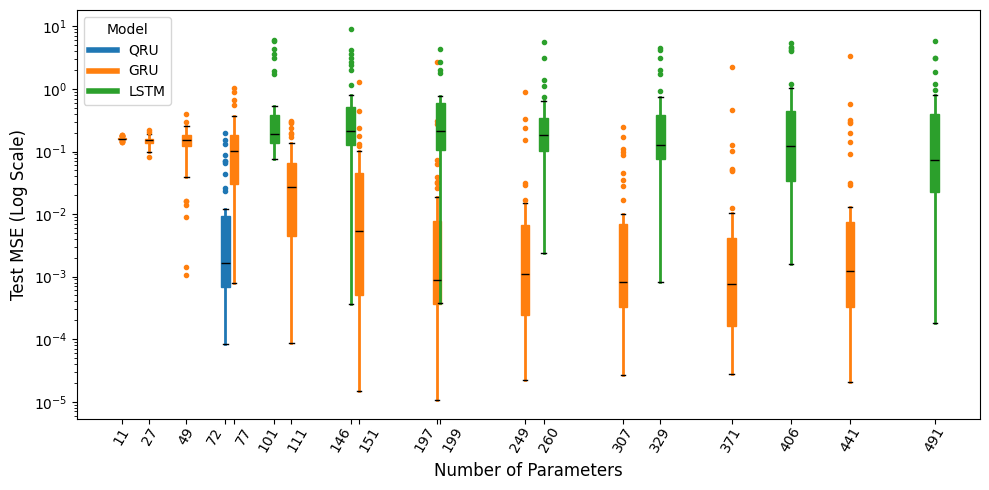

Chart saved as Test MSE.png


In [30]:
# List the uploaded files (adjust paths if necessary)
file_list = [
    './qru_test.csv',
    './gru_test.csv',
    './lstm_test - 2.csv',
    # './rnn_train.csv'
]

# Load data and generate the plot
data = load_data(file_list)
plot_box_chart_with_dual_xticks(data, 'Test MSE Distribution Across Parameter Counts',
                                'Number of Parameters', 'Test MSE (Log Scale)', 'Test MSE')


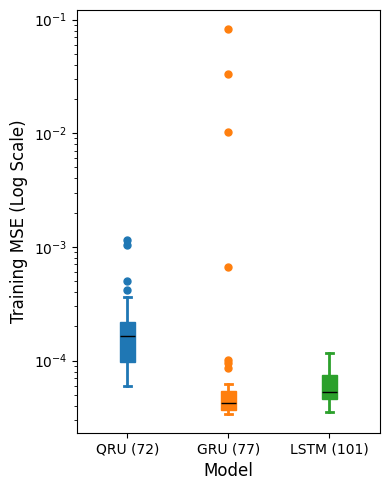

Boxplot saved as 'training_loss_boxplot_with_colors.png'


In [45]:
import csv
import matplotlib.pyplot as plt
from collections import defaultdict

# Load the data from CSV file
file_path = './Training loss.csv'
data = defaultdict(list)
models = []

with open(file_path, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)  # Read the header (first row)
    models = header[1:]  # Models are from the second column onward
    
    # Read the remaining rows
    for row in reader:
        exp = row[0]  # Experiment number (ignored for grouping here)
        for model, value in zip(models, row[1:]):  # Iterate over models and their values
            if value:  # Skip empty values
                data[model].append(float(value))

# Prepare data for the boxplot
box_data = [data[model] for model in models]  # Group data by model

# Plot the box chart
plt.figure(figsize=(4, 5))
colors = plt.cm.tab10(range(len(models)))  # Assign colors based on the number of models

for i, (model, model_data) in enumerate(data.items()):
    bp = plt.boxplot(
        [model_data],
        positions=[i],  # Position each model at a different x-axis location
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], color=colors[i]),
        whiskerprops=dict(color=colors[i], linewidth=2),
        capprops=dict(color=colors[i], linewidth=2),
        medianprops=dict(color='black'),
        flierprops=dict(markerfacecolor=colors[i], markeredgecolor=colors[i], marker='o', markersize=5),
    )

# Customize the plot
# plt.title("Training MSE Distribution Across Models", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Training MSE (Log Scale)", fontsize=12)
plt.xticks(ticks=range(len(models)), labels=models, rotation=0)  # Set x-axis labels
plt.yscale('log')  # Use logarithmic scale for y-axis

# Save and display the plot
plt.tight_layout()
plt.savefig("training_loss_boxplot_with_colors.png")
plt.show()
print("Boxplot saved as 'training_loss_boxplot_with_colors.png'")


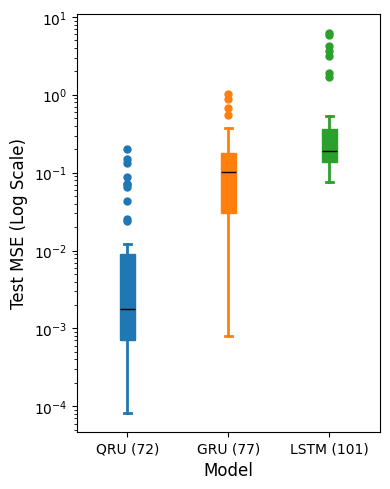

Boxplot saved as 'test_loss_boxplot_with_colors.png'


In [44]:
import csv
import matplotlib.pyplot as plt
from collections import defaultdict

# Load the data from CSV file
file_path = './Test loss.csv'
data = defaultdict(list)
models = []

with open(file_path, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)  # Read the header (first row)
    models = header[1:]  # Models are from the second column onward
    
    # Read the remaining rows
    for row in reader:
        exp = row[0]  # Experiment number (ignored for grouping here)
        for model, value in zip(models, row[1:]):  # Iterate over models and their values
            if value:  # Skip empty values
                data[model].append(float(value))

# Prepare data for the boxplot
box_data = [data[model] for model in models]  # Group data by model

# Plot the box chart
plt.figure(figsize=(4, 5))
colors = plt.cm.tab10(range(len(models)))  # Assign colors based on the number of models

for i, (model, model_data) in enumerate(data.items()):
    bp = plt.boxplot(
        [model_data],
        positions=[i],  # Position each model at a different x-axis location
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], color=colors[i]),
        whiskerprops=dict(color=colors[i], linewidth=2),
        capprops=dict(color=colors[i], linewidth=2),
        medianprops=dict(color='black'),
        flierprops=dict(markerfacecolor=colors[i], markeredgecolor=colors[i], marker='o', markersize=5),
    )

# Customize the plot
# plt.title("Test MSE Distribution Across Models", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Test MSE (Log Scale)", fontsize=12)
plt.xticks(ticks=range(len(models)), labels=models, rotation=0)  # Set x-axis labels
plt.yscale('log')  # Use logarithmic scale for y-axis

# Save and display the plot
plt.tight_layout()
plt.savefig("test_loss_boxplot_with_colors.png")
plt.show()
print("Boxplot saved as 'test_loss_boxplot_with_colors.png'")


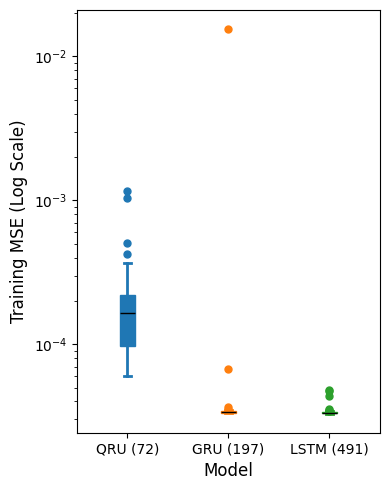

Boxplot saved as 'training_loss_boxplot_with_colors-2.png'


In [43]:
import csv
import matplotlib.pyplot as plt
from collections import defaultdict

# Load the data from CSV file
file_path = './Training loss - 2.csv'
data = defaultdict(list)
models = []

with open(file_path, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)  # Read the header (first row)
    models = header[1:]  # Models are from the second column onward
    
    # Read the remaining rows
    for row in reader:
        exp = row[0]  # Experiment number (ignored for grouping here)
        for model, value in zip(models, row[1:]):  # Iterate over models and their values
            if value:  # Skip empty values
                data[model].append(float(value))

# Prepare data for the boxplot
box_data = [data[model] for model in models]  # Group data by model

# Plot the box chart
plt.figure(figsize=(4, 5))
colors = plt.cm.tab10(range(len(models)))  # Assign colors based on the number of models

for i, (model, model_data) in enumerate(data.items()):
    bp = plt.boxplot(
        [model_data],
        positions=[i],  # Position each model at a different x-axis location
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], color=colors[i]),
        whiskerprops=dict(color=colors[i], linewidth=2),
        capprops=dict(color=colors[i], linewidth=2),
        medianprops=dict(color='black'),
        flierprops=dict(markerfacecolor=colors[i], markeredgecolor=colors[i], marker='o', markersize=5),
    )

# Customize the plot
# plt.title("Training MSE Distribution Across Models", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Training MSE (Log Scale)", fontsize=12)
plt.xticks(ticks=range(len(models)), labels=models, rotation=0)  # Set x-axis labels
plt.yscale('log')  # Use logarithmic scale for y-axis

# Save and display the plot
plt.tight_layout()
plt.savefig("training_loss_boxplot_with_colors-2.png")
plt.show()
print("Boxplot saved as 'training_loss_boxplot_with_colors-2.png'")


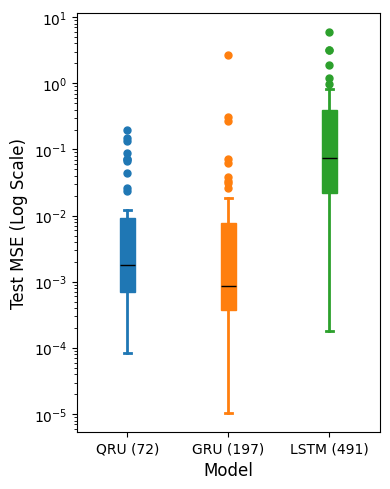

Boxplot saved as 'test_loss_boxplot_with_colors-2.png'


In [42]:
import csv
import matplotlib.pyplot as plt
from collections import defaultdict

# Load the data from CSV file
file_path = './Test loss - 2.csv'
data = defaultdict(list)
models = []

with open(file_path, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)  # Read the header (first row)
    models = header[1:]  # Models are from the second column onward
    
    # Read the remaining rows
    for row in reader:
        exp = row[0]  # Experiment number (ignored for grouping here)
        for model, value in zip(models, row[1:]):  # Iterate over models and their values
            if value:  # Skip empty values
                data[model].append(float(value))

# Prepare data for the boxplot
box_data = [data[model] for model in models]  # Group data by model

# Plot the box chart
plt.figure(figsize=(4, 5))
colors = plt.cm.tab10(range(len(models)))  # Assign colors based on the number of models

for i, (model, model_data) in enumerate(data.items()):
    bp = plt.boxplot(
        [model_data],
        positions=[i],  # Position each model at a different x-axis location
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], color=colors[i]),
        whiskerprops=dict(color=colors[i], linewidth=2),
        capprops=dict(color=colors[i], linewidth=2),
        medianprops=dict(color='black'),
        flierprops=dict(markerfacecolor=colors[i], markeredgecolor=colors[i], marker='o', markersize=5),
    )

# Customize the plot
# plt.title("Test MSE Distribution Across Models", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Test MSE (Log Scale)", fontsize=12)
plt.xticks(ticks=range(len(models)), labels=models, rotation=0)  # Set x-axis labels
plt.yscale('log')  # Use logarithmic scale for y-axis

# Save and display the plot
plt.tight_layout()
plt.savefig("test_loss_boxplot_with_colors-2.png")
plt.show()
print("Boxplot saved as 'test_loss_boxplot_with_colors-2.png'")
